# Cox Proportional Hazards Model in R

## Overview

The Cox PH model estimates the effect of covariates on the hazard — the instantaneous rate of the event occurring given survival to time t.

$$h(t | X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \ldots)$$

| Term | Meaning |
|---|---|
| $h_0(t)$ | Baseline hazard — unspecified non-parametric function of time |
| $\exp(\beta)$ | **Hazard ratio (HR)**: multiplicative change in hazard per unit increase in X |
| HR > 1 | Higher hazard = faster time to event |
| HR < 1 | Lower hazard = slower time to event (protective) |

**The proportional hazards assumption:** The ratio of hazards between any two subjects is constant over time. This is the key assumption — if violated, Cox PH results are misleading.

**When to use Cox vs. AFT:** Cox is semi-parametric (no distribution assumed for $h_0$) and produces hazard ratios — standard in medical and ecological literature. AFT (see `accelerated_failure_time.ipynb`) is parametric, produces time ratios, and may fit better when a specific distribution is appropriate.

---

## Setup

In [1]:
library(tidyverse)
library(survival)    # coxph(), cox.zph(), Surv()
library(survminer)   # ggsurvplot(), ggcoxzph(), ggforest()
library(broom)       # tidy(), glance()

set.seed(42)

# ── Simulate: time to invertebrate colonisation with multiple covariates ───────
n <- 200
cox_data <- tibble(
  id          = 1:n,
  habitat     = factor(sample(c("reference","restored","degraded"), n,
                              replace=TRUE, prob=c(0.35,0.35,0.30)),
                       levels=c("reference","restored","degraded")),
  water_qual  = rnorm(n, 6, 1.5),    # continuous: higher = better quality
  distance_km = rexp(n, rate=0.3)    # distance from source population
) %>%
  mutate(
    # True log-hazard: habitat (step from ref), water quality (protective), distance (risk)
    log_h   = case_when(
                habitat == "reference" ~ 0,
                habitat == "restored"  ~ 0.4,
                habitat == "degraded"  ~ 1.1
              ) - 0.3 * water_qual + 0.15 * distance_km,
    true_t  = rexp(n, rate = exp(log_h) * 0.05),
    status  = as.integer(true_t <= 60),
    time    = pmin(true_t, 60)
  )

cat(sprintf("%d / %d events observed\n", sum(cox_data$status), n))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'survival' was built under R version 4.4.3"
Warning message:
"package 'survminer' was built under R version

144 / 200 events observed


---

## Fitting the Cox Model

In [2]:
cox_fit <- coxph(
  Surv(time, status) ~ habitat + water_qual + distance_km,
  data    = cox_data,
  ties    = "efron"   # Efron (default): better than Breslow for tied event times
)
summary(cox_fit)
# Output includes:
#   coef:      log hazard ratio
#   exp(coef): hazard ratio (HR) — the primary effect size
#   se(coef):  standard error of log HR
#   z, p:      Wald test
#   lower/upper .95: 95% CI for HR
# Concordance: probability a higher-risk subject fails before lower-risk
#   (C-statistic; 0.5 = random, 1.0 = perfect)

# Tidy output
cox_tidy <- broom::tidy(cox_fit, exponentiate = TRUE, conf.int = TRUE)
print(cox_tidy)

Call:
coxph(formula = Surv(time, status) ~ habitat + water_qual + distance_km, 
    data = cox_data, ties = "efron")

  n= 200, number of events= 144 

                    coef exp(coef) se(coef)      z Pr(>|z|)    
habitatrestored  0.53160   1.70166  0.22064  2.409    0.016 *  
habitatdegraded  0.85838   2.35933  0.21278  4.034 5.48e-05 ***
water_qual      -0.27889   0.75663  0.05778 -4.826 1.39e-06 ***
distance_km      0.15998   1.17349  0.02616  6.115 9.64e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                exp(coef) exp(-coef) lower .95 upper .95
habitatrestored    1.7017     0.5877    1.1042    2.6223
habitatdegraded    2.3593     0.4238    1.5548    3.5802
water_qual         0.7566     1.3217    0.6756    0.8474
distance_km        1.1735     0.8522    1.1148    1.2352

Concordance= 0.68  (se = 0.022 )
Likelihood ratio test= 56.4  on 4 df,   p=2e-11
Wald test            = 60.34  on 4 df,   p=2e-12
Score (logrank) test = 63.08  on 4 df,   p=7

# A tibble: 4 × 7
  term            estimate std.error statistic  p.value conf.low conf.high
  <chr>              <dbl>     <dbl>     <dbl>    <dbl>    <dbl>     <dbl>
1 habitatrestored    1.70     0.221       2.41 1.60e- 2    1.10      2.62 
2 habitatdegraded    2.36     0.213       4.03 5.48e- 5    1.55      3.58 
3 water_qual         0.757    0.0578     -4.83 1.39e- 6    0.676     0.847
4 distance_km        1.17     0.0262      6.12 9.64e-10    1.11      1.24 


---

## Checking the Proportional Hazards Assumption

The PH assumption requires that the log hazard ratio for each covariate is constant over time. Violation means the effect of a covariate changes with time — the model is misspecified.

**Three complementary checks:**
1. Schoenfeld residuals (statistical test + plot)
2. Log-log survival plot (visual)
3. Time × covariate interaction (formal test)

            chisq df    p
habitat     1.613  2 0.45
water_qual  0.010  1 0.92
distance_km 0.513  1 0.47
GLOBAL      2.167  4 0.71


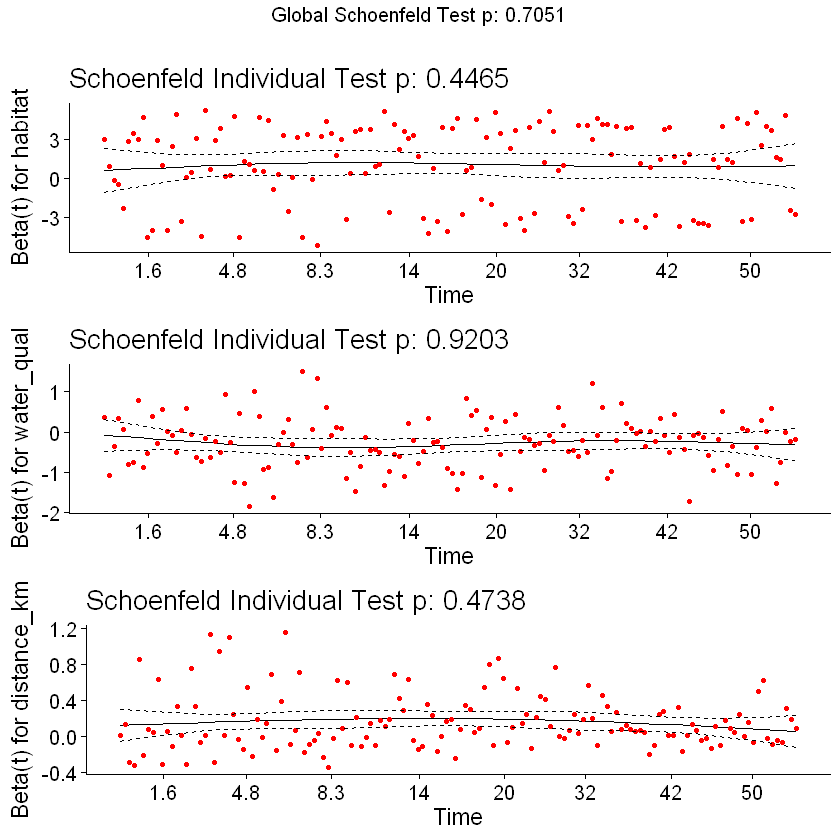

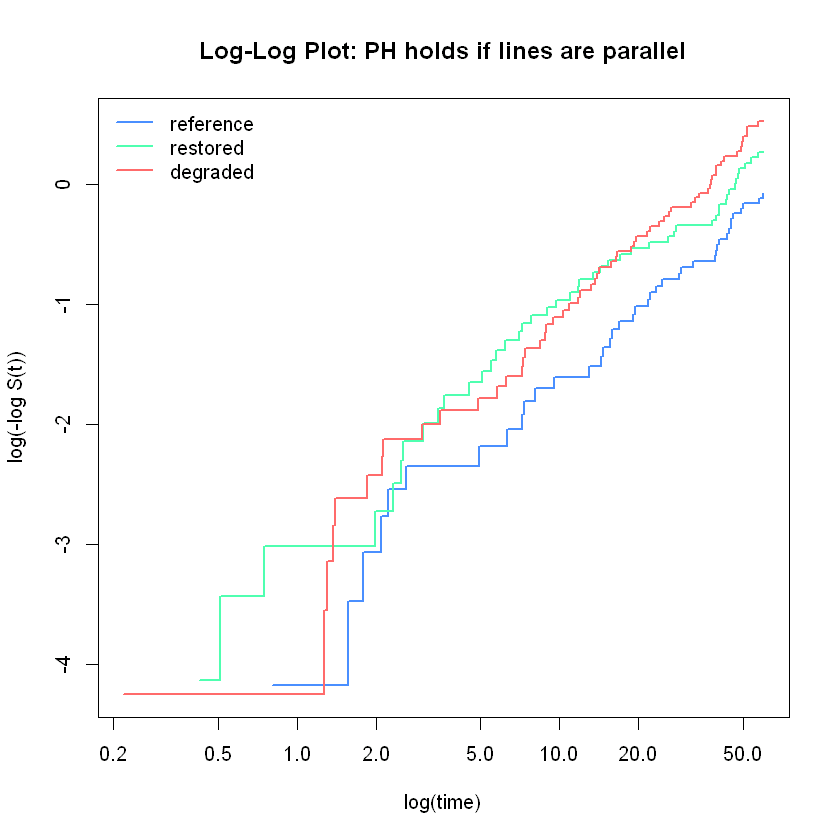

In [3]:
# ── 1. Schoenfeld residuals test ──────────────────────────────────────────────
ph_test <- cox.zph(cox_fit)
print(ph_test)
# GLOBAL: omnibus test for any PH violation
# Per-covariate: p > 0.05 → no evidence of PH violation for that variable
# p < 0.05 → hazard ratio changes over time → PH violated

# ── 2. Schoenfeld residual plots ──────────────────────────────────────────────
# Should show horizontal scatter around zero; trending pattern = PH violation
survminer::ggcoxzph(ph_test)

# ── 3. Log-log plot (visual PH check for categorical variables) ───────────────
km_habitat <- survfit(Surv(time, status) ~ habitat, data = cox_data)
plot(km_habitat, fun="cloglog",
     col=c("#4a8fff","#4fffb0","#ff6b6b"),
     lwd=2, xlab="log(time)", ylab="log(-log S(t))",
     main="Log-Log Plot: PH holds if lines are parallel")
legend("topleft", legend=levels(cox_data$habitat),
       col=c("#4a8fff","#4fffb0","#ff6b6b"), lwd=2, bty="n")
# Parallel lines → proportional hazards OK
# Crossing or converging lines → PH violated for this variable

---

## Handling PH Violations

In [4]:
# ── Option A: stratify by the violating variable ─────────────────────────────
# Allows a separate baseline hazard per stratum; no HR estimated for that variable
cox_strat <- coxph(
  Surv(time, status) ~ strata(habitat) + water_qual + distance_km,
  data = cox_data
)
summary(cox_strat)

# ── Option B: time-varying coefficient (tt() interaction) ─────────────────────
# Allows the effect of a covariate to change as a function of time
cox_tt <- coxph(
  Surv(time, status) ~ water_qual + distance_km +
    tt(distance_km),   # distance_km effect allowed to change with time
  data   = cox_data,
  tt     = function(x, t, ...) x * log(t)   # linear in log(t)
)
summary(cox_tt)
# If tt(distance_km) is significant: effect of distance_km changes with log(t)

# ── Option C: split follow-up and fit piecewise Cox ───────────────────────────
# Split at time 20: allow different HRs before and after
# Covered in time_varying_covariates.ipynb

Call:
coxph(formula = Surv(time, status) ~ strata(habitat) + water_qual + 
    distance_km, data = cox_data)

  n= 200, number of events= 144 

                coef exp(coef) se(coef)      z Pr(>|z|)    
water_qual  -0.28349   0.75315  0.05840 -4.855 1.21e-06 ***
distance_km  0.16171   1.17552  0.02623  6.166 7.00e-10 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

            exp(coef) exp(-coef) lower .95 upper .95
water_qual     0.7532     1.3278    0.6717    0.8445
distance_km    1.1755     0.8507    1.1166    1.2375

Concordance= 0.666  (se = 0.024 )
Likelihood ratio test= 48.8  on 2 df,   p=3e-11
Wald test            = 54.91  on 2 df,   p=1e-12
Score (logrank) test = 56.55  on 2 df,   p=5e-13


Call:
coxph(formula = Surv(time, status) ~ water_qual + distance_km + 
    tt(distance_km), data = cox_data, tt = function(x, t, ...) x * 
    log(t))

  n= 200, number of events= 144 

                    coef exp(coef) se(coef)      z Pr(>|z|)    
water_qual      -0.25510   0.77484  0.06081 -4.195 2.73e-05 ***
distance_km      0.15602   1.16885  0.04482  3.481 0.000499 ***
tt(distance_km) -0.01005   0.99000  0.01844 -0.545 0.585528    
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

                exp(coef) exp(-coef) lower .95 upper .95
water_qual         0.7748     1.2906    0.6878    0.8729
distance_km        1.1688     0.8555    1.0706    1.2762
tt(distance_km)    0.9900     1.0101    0.9549    1.0264

Concordance= 0.65  (se = 0.025 )
Likelihood ratio test= 39.68  on 3 df,   p=1e-08
Wald test            = 46.06  on 3 df,   p=5e-10
Score (logrank) test = 47.01  on 3 df,   p=3e-10


---

## Model Diagnostics

`geom_smooth()` using formula = 'y ~ x'


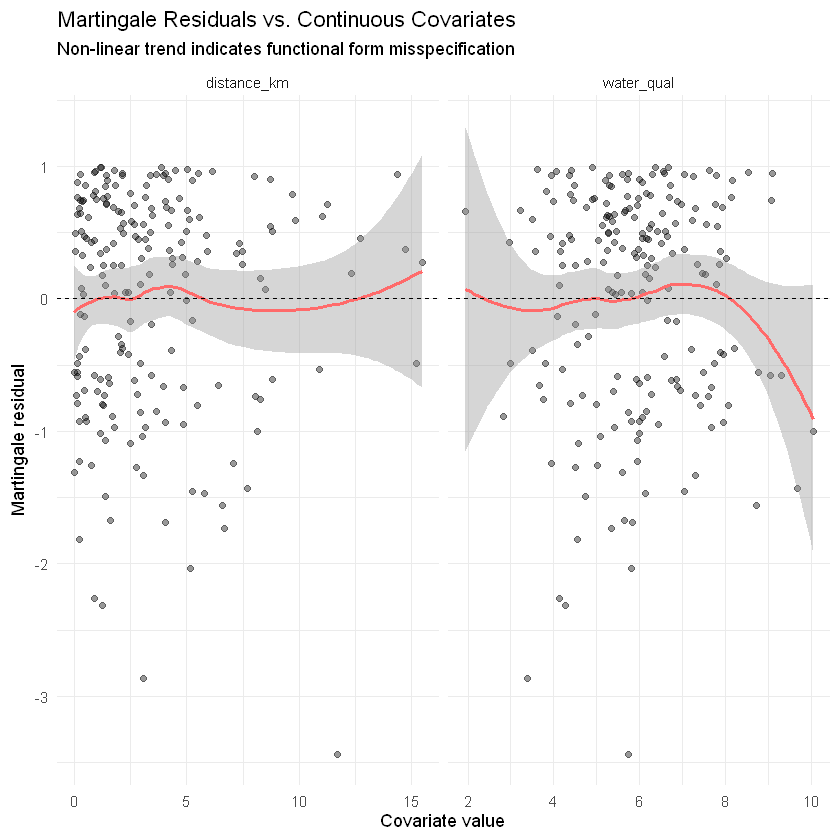

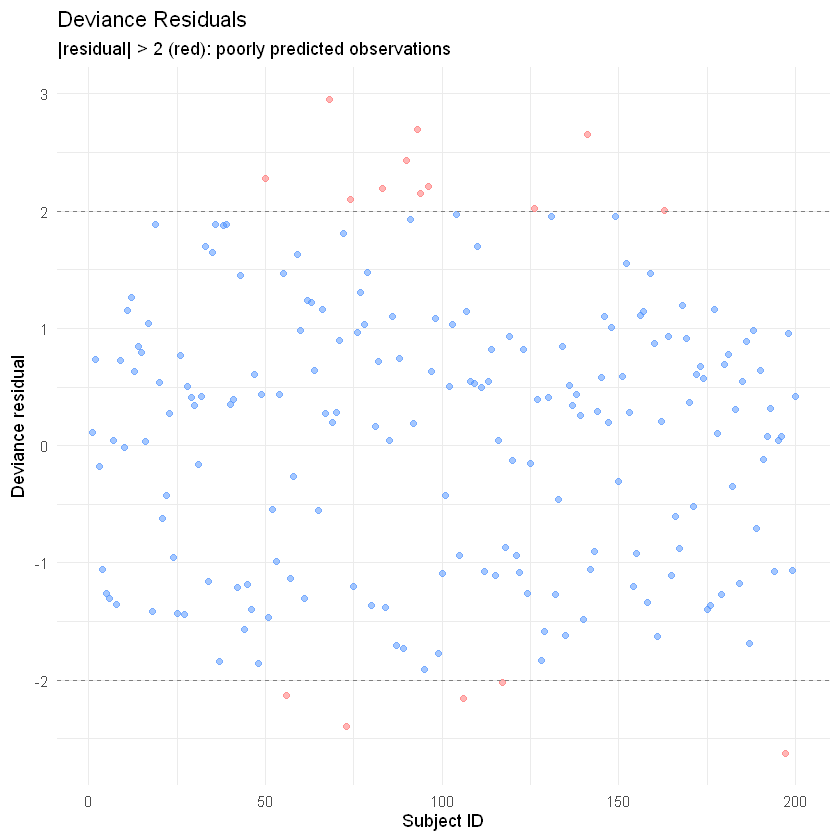

In [5]:
# ── Martingale residuals: detect non-linear covariate effects ─────────────────
mart_resid <- residuals(cox_fit, type="martingale")

# Plot vs. continuous covariates; should be approximately flat around 0
tibble(
  water_qual   = cox_data$water_qual,
  distance_km  = cox_data$distance_km,
  martingale   = mart_resid
) %>%
  pivot_longer(-martingale, names_to="covariate", values_to="value") %>%
  ggplot(aes(x=value, y=martingale)) +
  geom_point(alpha=0.4, size=1.5) +
  geom_smooth(method="loess", se=TRUE, color="#ff6b6b", linewidth=1) +
  geom_hline(yintercept=0, linetype="dashed") +
  facet_wrap(~covariate, scales="free_x") +
  labs(title="Martingale Residuals vs. Continuous Covariates",
       subtitle="Non-linear trend indicates functional form misspecification",
       x="Covariate value", y="Martingale residual") +
  theme_minimal()

# ── Deviance residuals: detect outliers / poorly fit subjects ─────────────────
dev_resid <- residuals(cox_fit, type="deviance")
tibble(id=cox_data$id, deviance=dev_resid) %>%
  ggplot(aes(x=id, y=deviance)) +
  geom_point(alpha=0.5, size=1.5,
             color=ifelse(abs(dev_resid) > 2, "#ff6b6b", "#4a8fff")) +
  geom_hline(yintercept=c(-2,2), linetype="dashed", color="gray50") +
  labs(title="Deviance Residuals",
       subtitle="|residual| > 2 (red): poorly predicted observations",
       x="Subject ID", y="Deviance residual") +
  theme_minimal()

---

## Forest Plot of Hazard Ratios

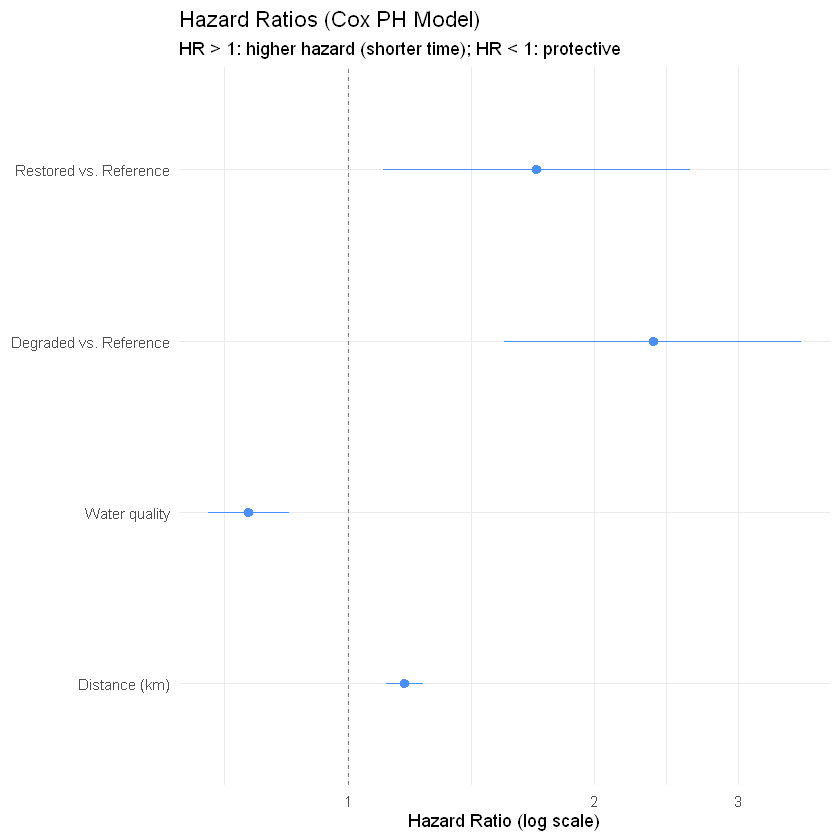

In [8]:
# ggplot2 forest plot — fully customisable
# Note: survminer::ggforest() has a known bug with mixed factor/continuous
# variables (names do not match previous names) — use ggplot2 directly instead
cox_tidy %>%
  filter(term != "(Intercept)") %>%
  mutate(term = factor(term,
    levels = c("habitatrestored", "habitatdegraded", "water_qual", "distance_km"),
    labels = c("Restored vs. Reference", "Degraded vs. Reference",
               "Water quality", "Distance (km)"))) %>%
  ggplot(aes(x = estimate, xmin = conf.low, xmax = conf.high, y = fct_rev(term))) +
  geom_pointrange(color = "#4a8fff") +
  geom_vline(xintercept = 1, linetype = "dashed", color = "gray50") +
  scale_x_log10() +
  labs(title    = "Hazard Ratios (Cox PH Model)",
       subtitle = "HR > 1: higher hazard (shorter time); HR < 1: protective",
       x = "Hazard Ratio (log scale)", y = NULL) +
  theme_minimal()

---

## Reporting Results

In [9]:
cat(sprintf("Concordance: %.3f\n", summary(cox_fit)$concordance[1]))
cat(sprintf("Global PH test (Schoenfeld): p=%.4f\n", ph_test$table["GLOBAL","p"]))
print(cox_tidy[, c("term","estimate","conf.low","conf.high","p.value")])

# Standard format:
# "A Cox proportional hazards model estimated the effect of habitat type,
#  water quality, and distance on time to colonisation. The proportional
#  hazards assumption was satisfied for all covariates (Schoenfeld
#  global test: p=.XXX). Degraded habitat was associated with a
#  X.X-fold higher hazard of colonisation failure compared to reference
#  sites (HR=X.X, 95% CI [X.X, X.X], p=.XXX). Each unit increase in
#  water quality reduced the hazard by XX% (HR=X.X [X.X, X.X]).
#  Model discrimination was good (C-statistic=0.XX)."
cat("\nReporting guidance above.\n")

Concordance: 0.680
Global PH test (Schoenfeld): p=0.7051
# A tibble: 4 × 5
  term            estimate conf.low conf.high  p.value
  <chr>              <dbl>    <dbl>     <dbl>    <dbl>
1 habitatrestored    1.70     1.10      2.62  1.60e- 2
2 habitatdegraded    2.36     1.55      3.58  5.48e- 5
3 water_qual         0.757    0.676     0.847 1.39e- 6
4 distance_km        1.17     1.11      1.24  9.64e-10

Reporting guidance above.


---

## Common Pitfalls

**1. Not testing the proportional hazards assumption**  
Cox PH is only valid when hazard ratios are constant over time. Always run `cox.zph()` and inspect Schoenfeld residual plots. Reporting results from a model with PH violations is a fundamental error.

**2. Interpreting hazard ratios as risk ratios**  
A HR is not the same as a relative risk or an odds ratio. HR > 1 means the event occurs at a higher instantaneous rate — not that the event is X times more likely overall. The distinction matters most when events are common.

**3. Ignoring the baseline hazard**  
The Cox model does not estimate $h_0(t)$ — it uses partial likelihood. Predicted survival probabilities (from `survfit(cox_fit)`) do estimate the baseline hazard cumulatively, but are less reliable than parametric AFT estimates when the distributional form is known.

**4. Using the Breslow tie-handling method for data with many ties**  
When many subjects share the same event time (common in discrete-time data), the Breslow approximation is biased. Use `ties="efron"` (the R default) or `ties="exact"` for small datasets.

**5. Not checking martingale residuals for functional form**  
A non-linear trend in martingale residuals vs. a continuous covariate means the log-linear relationship assumed by Cox PH is wrong. Try log-transforming the covariate or using a spline term: `pspline(water_qual)` in the formula.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*